In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

In [12]:
class MarksState(TypedDict):

    stats : int
    english : int
    hindi : int
    physics : int
    chemistry : int
    maths : int

    total_marks : str
    marks_percent : float
    result : str

In [38]:
def show_marks(state:MarksState):

    result = (state['stats']+ state['english']+ state['hindi']+ state['maths']+ state['physics']+ state['chemistry'])

    return {'total_marks':result}



def marks_percent(state:MarksState):

    result = (state['total_marks']/600)*100

    return {'marks_percent':result}



def Excellent(state:MarksState):
    result = f"Congrats you have secured more than 90% that is {state['marks_percent']}"

    return {'result':result}


def Pass(state:MarksState):
    result = f"congrats on passing the Exam with percent of {state['marks_percent']}"

    return {'result':result}


def Fail(state:MarksState):
    result = f"Very sorry that you couldnt pass the exam with percent of {state['marks_percent']}"

    return {'result':result}


def check_condition(state:MarksState) -> Literal['Excellent','Pass' , 'Fail']:

    if state['marks_percent'] > 90:
        return "Excellent"
    elif 60 <=  state['marks_percent'] < 90:
        return "Pass"
    else:
        return "Fail"

In [39]:
graph = StateGraph(MarksState)

graph.add_node('show_marks',show_marks)
graph.add_node('marks_percent',marks_percent)

graph.add_edge(START,'show_marks')
graph.add_edge('show_marks','marks_percent')

graph.add_conditional_edges('marks_percent',check_condition)

graph.add_node('Excellent',Excellent)
graph.add_node('Pass',Pass)
graph.add_node('Fail',Fail)

graph.add_edge('Excellent',END)
graph.add_edge('Pass',END)
graph.add_edge('Fail',END)

workflow = graph.compile()

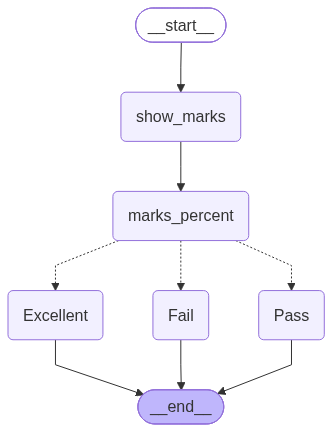

In [40]:
workflow

In [43]:
inital_flow = {
    'stats':100,
    'english':100,
    'hindi':100,
    'physics':100,
    'chemistry':100,
    'maths':100
}


workflow.invoke(inital_flow)

{'stats': 100,
 'english': 100,
 'hindi': 100,
 'physics': 100,
 'chemistry': 100,
 'maths': 100,
 'total_marks': 600,
 'marks_percent': 100.0,
 'result': 'Congrats you have secured more than 90% that is 100.0'}